# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import joblib


## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv(
    '../data/dayofweek.csv',
    index_col=0
)
df.head(3)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
X=df.drop(columns="dayofweek")
y=df["dayofweek"]
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [4]:
print(f"Train values: {y_train.value_counts(normalize=True)}")
print(f"Test values: {y_test.value_counts(normalize=True)}")

Train values: dayofweek
3    0.232196
6    0.212908
1    0.164688
5    0.160237
2    0.092730
0    0.077893
4    0.059347
Name: proportion, dtype: float64
Test values: dayofweek
3    0.245562
6    0.204142
5    0.162722
1    0.153846
0    0.091716
4    0.071006
2    0.071006
Name: proportion, dtype: float64


In [5]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [6]:
print(f"Train values: {y_train.value_counts(normalize=True)}")
print(f"Test values: {y_test.value_counts(normalize=True)}")

Train values: dayofweek
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64
Test values: dayofweek
3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: proportion, dtype: float64


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [7]:
logreg = LogisticRegression(
    random_state=21,
    fit_intercept=False
)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy logreg: {accuracy}")

Accuracy logreg: 0.6331360946745562


### b. SVM

In [8]:
svc = SVC(
    kernel='linear',
    probability=True,
    random_state=21
)

In [9]:
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [10]:
print(f"Accuracy svc: {accuracy}")

Accuracy svc: 0.7159763313609467


### c. Decision tree

In [11]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [12]:
print("Tree accuracy:", accuracy)

Tree accuracy: 0.5295857988165681


### d. Random forest

In [13]:
randForest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
randForest.fit(X_train, y_train)
y_pred = randForest.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [14]:
print("Random Forest accuracy:", accuracy)

Random Forest accuracy: 0.9289940828402367


## Показали ли все модели схожие значения метрики? Какая из них имеет наибольшую разницу при сравнении текущего упражнения с предыдущим?

Ответ: все модели показали в целом схожие значения метрики, разницу можно отчетливо заметить на модели RandomForestClassifier т.к раньше значение было 1.0 а теперь 0.92 и тут как раз заметно что раньше результаты были очевидно неправдивы.

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [15]:
logreg = LogisticRegression(
    random_state=21,
    fit_intercept=False
)

In [16]:
scores = cross_val_score(logreg,X,y,cv=10, scoring='accuracy')

In [17]:
print(f"Mean accuracy logreg: {scores.mean()}")
print(f"Standard deviation accuracy logreg: {scores.std()}")

Mean accuracy logreg: 0.45055649478726406
Standard deviation accuracy logreg: 0.16246520056822297


### b. SVM

In [18]:
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(f"Mean accuracy logreg: {scores.mean()}")
print(f"Standard deviation accuracy logreg: {scores.std()}")

Mean accuracy logreg: 0.5051986475063398
Standard deviation accuracy logreg: 0.15857963555262297


### c. Decision tree

In [19]:
scores = cross_val_score(tree, X, y, cv=10, scoring='accuracy')
print(f"Mean accuracy logreg: {scores.mean()}")
print(f"Standard deviation accuracy logreg: {scores.std()}")

Mean accuracy logreg: 0.3883523527754297
Standard deviation accuracy logreg: 0.11835394295385691


### d. Random forest

In [20]:
scores = cross_val_score(randForest, X, y, cv=10, scoring='accuracy')
print(f"Mean accuracy logreg: {scores.mean()}")
print(f"Standard deviation accuracy logreg: {scores.std()}")

Mean accuracy logreg: 0.6607847280924204
Standard deviation accuracy logreg: 0.17462799234675505


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [21]:
bestRandForest = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=21)
scores = cross_val_score(bestRandForest, X, y, cv=10, scoring='accuracy')
print(f"Mean accuracy rand forest: {scores.mean()}")
print(f"Standard deviation accuracy rand forest: {scores.std()}")


Mean accuracy rand forest: 0.6738165680473372
Standard deviation accuracy rand forest: 0.15890870303345517


In [22]:
bestRandForest.fit(X_train, y_train)
y_pred = bestRandForest.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy rand forest: {accuracy}")


Accuracy rand forest: 0.9319526627218935


In [23]:
def plot_feature_importance(coefs, features, top_n=10):
    
    importance = np.mean(np.abs(coefs), axis=0)
    
    feat_importance = pd.Series(importance, index=features)
    top_feats = feat_importance.sort_values(ascending=True).tail(top_n)
    
    plt.figure(figsize=(10, 6))
    top_feats.plot(kind='barh', color='skyblue')
    plt.title(f'Top {top_n} Most Important Features (Logistic Regression)')
    plt.xlabel('Mean Absolute Coefficient Value')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

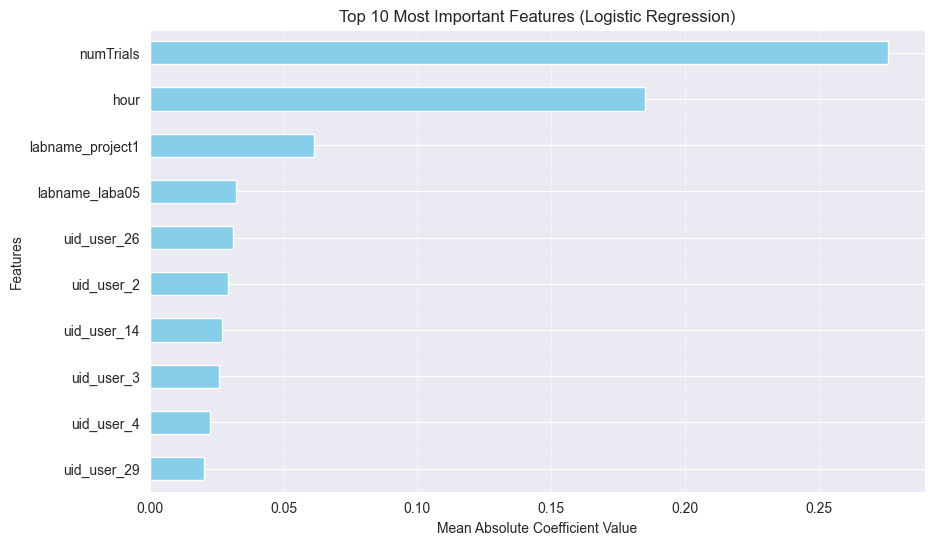

In [24]:
plot_feature_importance([bestRandForest.feature_importances_], X_test.columns, top_n=10)

In [25]:
joblib.dump(bestRandForest, 'RandForestModel.joblib')

['RandForestModel.joblib']

In [26]:
LoadModel = joblib.load('RandForestModel.joblib')
y_pred = LoadModel.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy load RandForest: {accuracy}")

Accuracy load RandForest: 0.9319526627218935
